In [9]:
from typing import List, TypedDict
from langgraph.graph import StateGraph
# StateGraph is a framework that help to design and manage the flow of tasks using graph structure.

In [10]:
class AgentState(TypedDict): 
    name: str
    age: str
    final: str

In [11]:
def first_node(state: AgentState) -> AgentState:
    """This is the first node of graph"""
    state["final"] = f"Hi there, {state['name']}!"
    return state
def second_node(state: AgentState) -> AgentState:
    """This is the s""econd node of graph"""
    state['final'] = state["final"] + f" You are {state['age']} years old"
    return state

In [12]:
graph = StateGraph(AgentState)
graph.set_entry_point('first-node')
graph.add_node('first-node', first_node)
graph.add_edge('first-node', 'second-node')
graph.add_node('second-node', second_node)
graph.set_finish_point('second-node')
app = graph.compile()

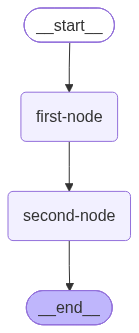

In [13]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [14]:
answer = app.invoke({'name': 'Charly', 'age': 24})
answer

{'name': 'Charly',
 'age': 24,
 'final': 'Hi there, Charly! You are 24 years old'}